# Additional Evaluation Experiments

This notebook adds the missing experimental evidence requested during thesis review:

1. Concurrency and load testing for the FastAPI prediction endpoint.
2. Cold-start latency measurement for the local API service.
3. Cost-sensitive threshold analysis with an explicit cost matrix.
4. Feature-engineering ablation study comparing base features against engineered features.

The notebook is designed to run as an additional evidence notebook after the core modeling, API, and dashboard notebooks have been completed.

## Review Context

The thesis already reports sequential API latency over 100 local calls. The review asks for stronger evidence around concurrent users, load testing, cold-start behavior, cost-sensitive thresholding, and feature-engineering ablation. These experiments are separated from the original modeling notebook so the original pipeline remains stable while the extra evidence can be rerun when needed.

In [1]:
from pathlib import Path
import os
import sys
import json
import time
import socket
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier


def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    if (current / "data").exists() and (current / "models").exists():
        return current
    if current.name == "notebooks" and (current.parent / "data").exists():
        return current.parent
    for parent in current.parents:
        if (parent / "data").exists() and (parent / "models").exists():
            return parent
    raise RuntimeError("Could not locate project root. Run this notebook inside fraud-detection-xai.")


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports" / "additional_experiments"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Additional experiment report directory:", REPORT_DIR)

Project root: C:\Users\ADMIN\fraud-detection-xai
Additional experiment report directory: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments


## 1. Concurrency and Load Testing

This section sends real HTTP requests to the running FastAPI service. It measures whether the API can handle multiple concurrent clients, not only one sequential caller.

Before running this section, start the API in a separate terminal:

```powershell
uvicorn api.main:app --reload --host 127.0.0.1 --port 8000
```

The output files are:

- `reports/additional_experiments/concurrency_test_raw.csv`
- `reports/additional_experiments/concurrency_test_summary.csv`
- `reports/additional_experiments/figures/concurrency_latency_by_users.png`

API health response: {'status': 'ok', 'model_loaded': True, 'threshold_loaded': True, 'feature_count': 47}
Running load test: 1 concurrent users, 10 total requests


Running load test: 5 concurrent users, 50 total requests


Running load test: 10 concurrent users, 100 total requests


Running load test: 20 concurrent users, 200 total requests


Running load test: 50 concurrent users, 500 total requests


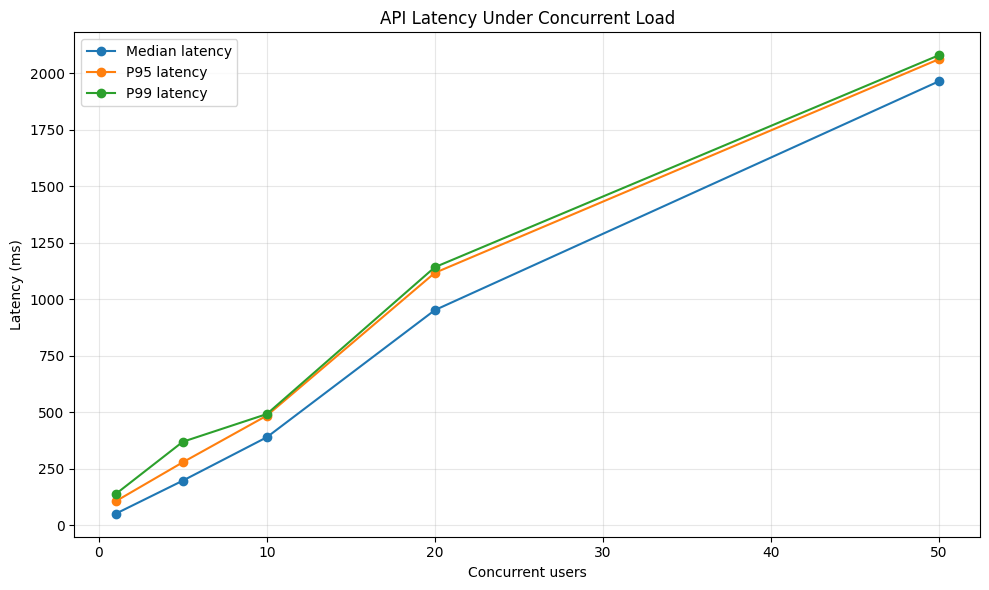

Saved raw results to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\concurrency_test_raw.csv
Saved summary to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\concurrency_test_summary.csv
Saved figure to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\figures\concurrency_latency_by_users.png


,concurrent_users,requests_per_user,total_requests,successful_requests,failed_requests,error_rate,wall_time_s,throughput_requests_per_s,mean_latency_ms,median_latency_ms,p95_latency_ms,p99_latency_ms,min_latency_ms,max_latency_ms
0,1,10,10,10,0,0.0,0.617672,16.189809,60.902380,51.65570,106.707585,138.573597,43.4772,146.5401
1,5,10,50,50,0,0.0,2.119500,23.590469,206.490632,198.18150,279.353155,370.043065,106.2412,375.2329
2,10,10,100,100,0,0.0,3.989268,25.067255,390.605705,389.98655,485.497475,492.536707,225.3971,527.6923
3,20,10,200,200,0,0.0,9.441417,21.183260,923.494067,952.10350,1116.852805,1141.813006,273.1378,1186.9964
4,50,10,500,500,0,0.0,19.818061,25.229511,1899.438523,1963.82930,2061.479860,2078.981160,246.3870,2087.4946


In [2]:
BASE_URL = os.getenv("FRAUD_API_BASE_URL", "http://127.0.0.1:8000").rstrip("/")
SAMPLE_PAYLOAD_PATH = PROJECT_ROOT / "reports" / "sample_transaction_payload.json"

CONCURRENT_USERS = [1, 5, 10, 20, 50]
REQUESTS_PER_USER = 10
REQUEST_TIMEOUT = 30

with open(SAMPLE_PAYLOAD_PATH, "r", encoding="utf-8") as f:
    sample_features = json.load(f)

health_response = requests.get(f"{BASE_URL}/health", timeout=REQUEST_TIMEOUT)
health_response.raise_for_status()
print("API health response:", health_response.json())


def call_predict(request_id: int, concurrent_users: int) -> dict:
    payload = {
        "transaction_id": f"load_test_u{concurrent_users}_req{request_id}",
        "features": sample_features,
    }

    start = time.perf_counter()
    try:
        response = requests.post(
            f"{BASE_URL}/predict",
            json=payload,
            timeout=REQUEST_TIMEOUT,
        )
        latency_ms = (time.perf_counter() - start) * 1000
        response_json = response.json() if response.text else {}

        return {
            "concurrent_users": concurrent_users,
            "request_id": request_id,
            "status_code": response.status_code,
            "success": response.status_code == 200,
            "latency_ms": latency_ms,
            "fraud_probability": response_json.get("fraud_probability"),
            "prediction": response_json.get("prediction"),
            "error": None if response.status_code == 200 else str(response_json)[:500],
        }
    except Exception as exc:
        latency_ms = (time.perf_counter() - start) * 1000
        return {
            "concurrent_users": concurrent_users,
            "request_id": request_id,
            "status_code": None,
            "success": False,
            "latency_ms": latency_ms,
            "fraud_probability": None,
            "prediction": None,
            "error": repr(exc),
        }


raw_results = []
summary_rows = []

for users in CONCURRENT_USERS:
    total_requests = users * REQUESTS_PER_USER
    print(f"Running load test: {users} concurrent users, {total_requests} total requests")

    wall_start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=users) as executor:
        futures = [
            executor.submit(call_predict, request_id, users)
            for request_id in range(total_requests)
        ]
        for future in as_completed(futures):
            raw_results.append(future.result())
    wall_time_s = time.perf_counter() - wall_start

    batch_df = pd.DataFrame([row for row in raw_results if row["concurrent_users"] == users])
    success_df = batch_df[batch_df["success"]]

    summary_rows.append({
        "concurrent_users": users,
        "requests_per_user": REQUESTS_PER_USER,
        "total_requests": total_requests,
        "successful_requests": int(batch_df["success"].sum()),
        "failed_requests": int((~batch_df["success"]).sum()),
        "error_rate": float((~batch_df["success"]).mean()),
        "wall_time_s": wall_time_s,
        "throughput_requests_per_s": total_requests / wall_time_s if wall_time_s > 0 else np.nan,
        "mean_latency_ms": success_df["latency_ms"].mean(),
        "median_latency_ms": success_df["latency_ms"].median(),
        "p95_latency_ms": success_df["latency_ms"].quantile(0.95),
        "p99_latency_ms": success_df["latency_ms"].quantile(0.99),
        "min_latency_ms": success_df["latency_ms"].min(),
        "max_latency_ms": success_df["latency_ms"].max(),
    })

concurrency_raw_df = pd.DataFrame(raw_results)
concurrency_summary_df = pd.DataFrame(summary_rows)

raw_path = REPORT_DIR / "concurrency_test_raw.csv"
summary_path = REPORT_DIR / "concurrency_test_summary.csv"
figure_path = FIGURE_DIR / "concurrency_latency_by_users.png"

concurrency_raw_df.to_csv(raw_path, index=False)
concurrency_summary_df.to_csv(summary_path, index=False)

plt.figure(figsize=(10, 6))
plt.plot(
    concurrency_summary_df["concurrent_users"],
    concurrency_summary_df["median_latency_ms"],
    marker="o",
    label="Median latency",
)
plt.plot(
    concurrency_summary_df["concurrent_users"],
    concurrency_summary_df["p95_latency_ms"],
    marker="o",
    label="P95 latency",
)
plt.plot(
    concurrency_summary_df["concurrent_users"],
    concurrency_summary_df["p99_latency_ms"],
    marker="o",
    label="P99 latency",
)
plt.xlabel("Concurrent users")
plt.ylabel("Latency (ms)")
plt.title("API Latency Under Concurrent Load")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved raw results to:", raw_path)
print("Saved summary to:", summary_path)
print("Saved figure to:", figure_path)
concurrency_summary_df

## 2. Cold-Start Latency

This section measures the local API cold-start behavior by launching a fresh Uvicorn process on a temporary free port. It records:

- API startup time until `/health` responds.
- First prediction latency after startup.
- Warm prediction latency after the first request.

The output files are:

- `reports/additional_experiments/cold_start_latency_summary.csv`
- `reports/additional_experiments/cold_start_latency_raw.csv`

In [3]:
def find_free_port() -> int:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("127.0.0.1", 0))
        return int(s.getsockname()[1])


def wait_for_health(base_url: str, timeout_s: float = 60.0) -> float:
    start = time.perf_counter()
    last_error = None

    while time.perf_counter() - start < timeout_s:
        try:
            response = requests.get(f"{base_url}/health", timeout=2)
            if response.status_code == 200:
                return (time.perf_counter() - start) * 1000
        except Exception as exc:
            last_error = exc
        time.sleep(0.2)

    raise TimeoutError(f"API did not become healthy within {timeout_s}s. Last error: {last_error}")


def terminate_process(process: subprocess.Popen) -> None:
    if process.poll() is None:
        process.terminate()
        try:
            process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait(timeout=10)


COLD_START_RUNS = 3
WARM_REQUESTS_PER_RUN = 20
cold_start_rows = []
warm_latency_rows = []

for run_id in range(1, COLD_START_RUNS + 1):
    port = find_free_port()
    base_url = f"http://127.0.0.1:{port}"
    stdout_path = REPORT_DIR / f"cold_start_run_{run_id}_stdout.log"
    stderr_path = REPORT_DIR / f"cold_start_run_{run_id}_stderr.log"

    env = os.environ.copy()
    env["PYTHONPATH"] = str(PROJECT_ROOT)

    with open(stdout_path, "w", encoding="utf-8") as stdout_file, open(stderr_path, "w", encoding="utf-8") as stderr_file:
        process = subprocess.Popen(
            [
                sys.executable,
                "-m",
                "uvicorn",
                "api.main:app",
                "--host",
                "127.0.0.1",
                "--port",
                str(port),
            ],
            cwd=PROJECT_ROOT,
            env=env,
            stdout=stdout_file,
            stderr=stderr_file,
        )

        try:
            startup_latency_ms = wait_for_health(base_url)

            payload = {
                "transaction_id": f"cold_start_run_{run_id}_first_request",
                "features": sample_features,
            }

            first_start = time.perf_counter()
            first_response = requests.post(f"{base_url}/predict", json=payload, timeout=30)
            first_latency_ms = (time.perf_counter() - first_start) * 1000
            first_response.raise_for_status()

            warm_latencies = []
            for request_id in range(WARM_REQUESTS_PER_RUN):
                warm_payload = {
                    "transaction_id": f"cold_start_run_{run_id}_warm_{request_id}",
                    "features": sample_features,
                }
                warm_start = time.perf_counter()
                warm_response = requests.post(f"{base_url}/predict", json=warm_payload, timeout=30)
                warm_latency_ms = (time.perf_counter() - warm_start) * 1000
                warm_response.raise_for_status()
                warm_latencies.append(warm_latency_ms)
                warm_latency_rows.append({
                    "run_id": run_id,
                    "request_id": request_id,
                    "latency_ms": warm_latency_ms,
                })

            cold_start_rows.append({
                "run_id": run_id,
                "startup_latency_ms": startup_latency_ms,
                "first_prediction_latency_ms": first_latency_ms,
                "warm_requests": WARM_REQUESTS_PER_RUN,
                "warm_mean_latency_ms": float(np.mean(warm_latencies)),
                "warm_median_latency_ms": float(np.median(warm_latencies)),
                "warm_p95_latency_ms": float(np.percentile(warm_latencies, 95)),
                "warm_p99_latency_ms": float(np.percentile(warm_latencies, 99)),
                "warm_min_latency_ms": float(np.min(warm_latencies)),
                "warm_max_latency_ms": float(np.max(warm_latencies)),
                "stdout_log": str(stdout_path),
                "stderr_log": str(stderr_path),
            })
        finally:
            terminate_process(process)

cold_start_summary_df = pd.DataFrame(cold_start_rows)
cold_start_raw_df = pd.DataFrame(warm_latency_rows)

summary_path = REPORT_DIR / "cold_start_latency_summary.csv"
raw_path = REPORT_DIR / "cold_start_latency_raw.csv"

cold_start_summary_df.to_csv(summary_path, index=False)
cold_start_raw_df.to_csv(raw_path, index=False)

print("Saved cold-start summary to:", summary_path)
print("Saved warm request raw data to:", raw_path)
cold_start_summary_df

Saved cold-start summary to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\cold_start_latency_summary.csv
Saved warm request raw data to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\cold_start_latency_raw.csv


,run_id,startup_latency_ms,first_prediction_latency_ms,warm_requests,warm_mean_latency_ms,warm_median_latency_ms,warm_p95_latency_ms,warm_p99_latency_ms,warm_min_latency_ms,warm_max_latency_ms,stdout_log,stderr_log
0,1,4980.1966,44.9900,20,41.147915,39.66220,46.50282,53.023924,38.5231,54.6542,C:\Users\ADMIN\fraud-detection-xai\reports\add...,C:\Users\ADMIN\fraud-detection-xai\reports\add...
1,2,4472.6235,45.9936,20,52.627150,49.78355,67.94837,90.247834,39.7115,95.8227,C:\Users\ADMIN\fraud-detection-xai\reports\add...,C:\Users\ADMIN\fraud-detection-xai\reports\add...
2,3,6015.6884,63.2509,20,39.842795,38.93535,46.00800,47.980960,36.8815,48.4742,C:\Users\ADMIN\fraud-detection-xai\reports\add...,C:\Users\ADMIN\fraud-detection-xai\reports\add...


## 3. Cost-Sensitive Threshold Analysis

The original threshold was selected mainly using validation F1-score. This section adds an explicit business-cost view.

Assumption used in this notebook:

- False Negative cost: `100`
- False Positive cost: `5`
- True Positive and True Negative cost: `0`

The formula is:

```text
Total cost = FN x cost_FN + FP x cost_FP
```

The output files are:

- `reports/additional_experiments/cost_sensitive_threshold_results.csv`
- `reports/additional_experiments/cost_sensitive_threshold_summary.csv`
- `reports/additional_experiments/figures/cost_sensitive_threshold_curve.png`

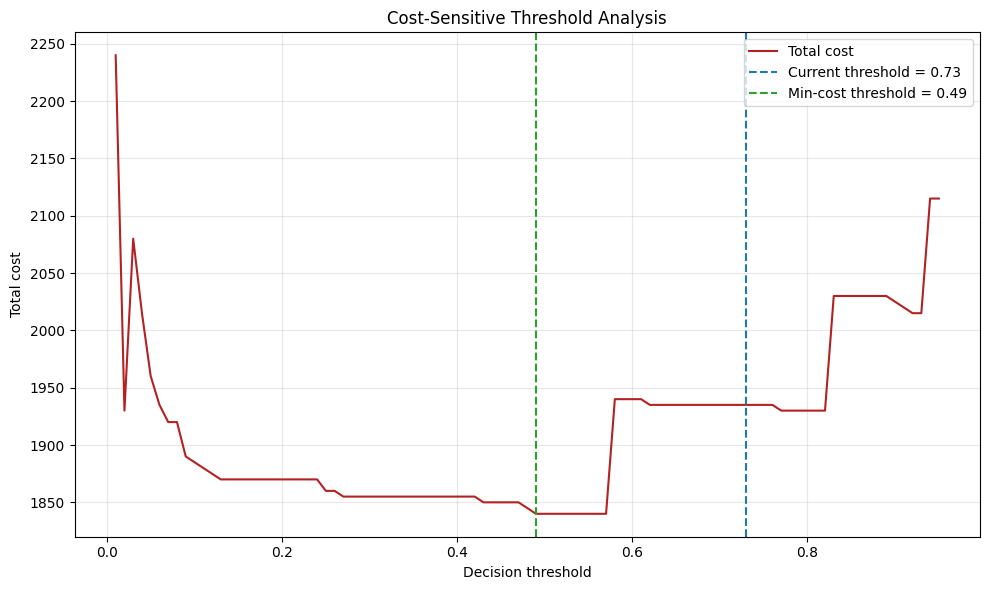

Cost matrix:


,Predicted Non-fraud,Predicted Fraud
Actual Non-fraud,0,5
Actual Fraud,100,0


Saved threshold results to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\cost_sensitive_threshold_results.csv
Saved summary to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\cost_sensitive_threshold_summary.csv
Saved figure to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\figures\cost_sensitive_threshold_curve.png


,policy,threshold,true_negative,false_positive,false_negative,true_positive,precision,recall,f1,false_alert_rate,fraud_capture_rate,total_cost,cost_false_negative,cost_false_positive
0,minimum_cost_threshold,0.49,56879.0,8.0,18.0,57.0,0.876923,0.760000,0.814286,0.000141,0.760000,1840.0,100.0,5.0
1,current_f1_selected_threshold,0.73,56880.0,7.0,19.0,56.0,0.888889,0.746667,0.811594,0.000123,0.746667,1935.0,100.0,5.0


In [4]:
final_model = joblib.load(MODEL_DIR / "final_fraud_model.pkl")
best_threshold = float(joblib.load(MODEL_DIR / "best_threshold.pkl"))
feature_list = joblib.load(MODEL_DIR / "feature_list.pkl")

test_df = pd.read_csv(DATA_DIR / "processed" / "test_fe.csv")
X_test = test_df[feature_list]
y_test = test_df["Class"].astype(int)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

COST_FALSE_NEGATIVE = 100
COST_FALSE_POSITIVE = 5
THRESHOLDS = np.round(np.arange(0.01, 0.96, 0.01), 2)

cost_matrix = pd.DataFrame(
    [
        [0, COST_FALSE_POSITIVE],
        [COST_FALSE_NEGATIVE, 0],
    ],
    index=["Actual Non-fraud", "Actual Fraud"],
    columns=["Predicted Non-fraud", "Predicted Fraud"],
)

cost_rows = []
for threshold in THRESHOLDS:
    y_pred = (y_test_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    total_cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE

    cost_rows.append({
        "threshold": threshold,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "false_alert_rate": fp / (fp + tn) if (fp + tn) else 0,
        "fraud_capture_rate": tp / (tp + fn) if (tp + fn) else 0,
        "total_cost": int(total_cost),
        "cost_false_negative": COST_FALSE_NEGATIVE,
        "cost_false_positive": COST_FALSE_POSITIVE,
    })

cost_threshold_df = pd.DataFrame(cost_rows)
minimum_cost_row = cost_threshold_df.sort_values(
    by=["total_cost", "false_negative", "false_positive", "threshold"],
    ascending=[True, True, True, True],
).iloc[0]
selected_threshold_row = cost_threshold_df.loc[
    cost_threshold_df["threshold"].round(2) == round(best_threshold, 2)
].iloc[0]

cost_summary_df = pd.DataFrame([
    {
        "policy": "minimum_cost_threshold",
        **minimum_cost_row.to_dict(),
    },
    {
        "policy": "current_f1_selected_threshold",
        **selected_threshold_row.to_dict(),
    },
])

results_path = REPORT_DIR / "cost_sensitive_threshold_results.csv"
summary_path = REPORT_DIR / "cost_sensitive_threshold_summary.csv"
figure_path = FIGURE_DIR / "cost_sensitive_threshold_curve.png"

cost_threshold_df.to_csv(results_path, index=False)
cost_summary_df.to_csv(summary_path, index=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(cost_threshold_df["threshold"], cost_threshold_df["total_cost"], color="#b22222", label="Total cost")
ax1.axvline(best_threshold, color="#1f77b4", linestyle="--", label=f"Current threshold = {best_threshold:.2f}")
ax1.axvline(float(minimum_cost_row["threshold"]), color="#2ca02c", linestyle="--", label=f"Min-cost threshold = {minimum_cost_row['threshold']:.2f}")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Total cost")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")
plt.title("Cost-Sensitive Threshold Analysis")
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Cost matrix:")
display(cost_matrix)
print("Saved threshold results to:", results_path)
print("Saved summary to:", summary_path)
print("Saved figure to:", figure_path)
cost_summary_df

## 4. Feature-Engineering Ablation Study

This section compares two XGBoost experiments under the same time-based design:

- **Base features:** `Time`, `Amount`, and `V1` to `V28` from the original Kaggle dataset.
- **Engineered features:** the 47 model-ready features created during the feature engineering stage.

For each setting, the notebook:

1. Splits the training period into chronological train/validation subsets.
2. Trains an XGBoost validation model.
3. Tunes the threshold on validation data by fraud-class F1-score.
4. Retrains XGBoost on the full training period.
5. Evaluates on the held-out test period.

The output files are:

- `reports/additional_experiments/feature_engineering_ablation_results.csv`
- `reports/additional_experiments/feature_engineering_ablation_confusion_matrices.csv`
- `reports/additional_experiments/figures/feature_engineering_ablation_metrics.png`

Running ablation experiment: base_features


Running ablation experiment: engineered_features


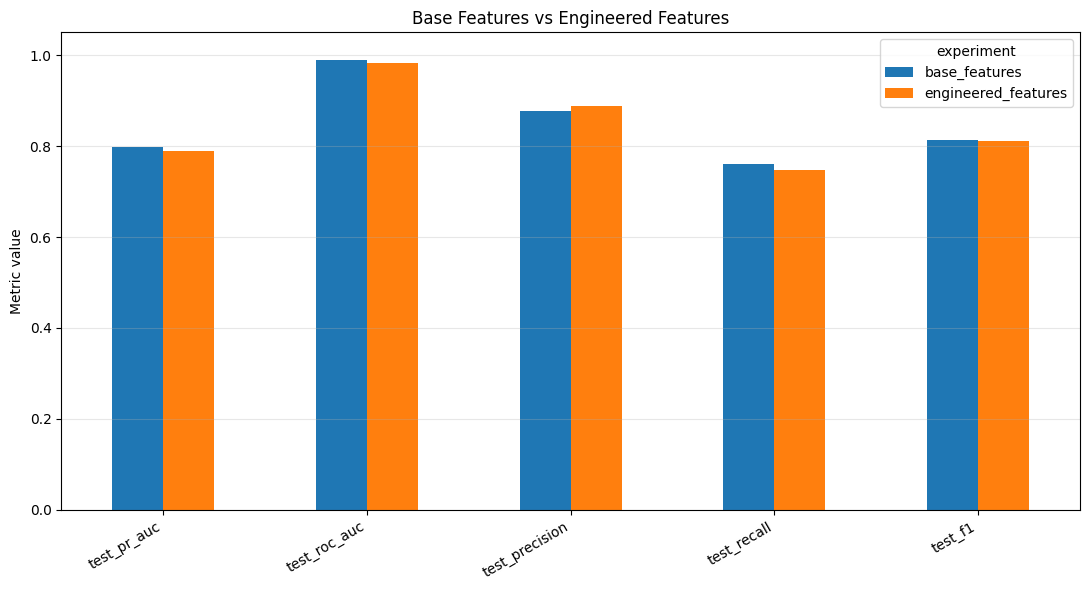

Saved ablation results to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\feature_engineering_ablation_results.csv
Saved ablation confusion matrices to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\feature_engineering_ablation_confusion_matrices.csv
Saved ablation threshold table to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\feature_engineering_ablation_thresholds.csv
Saved figure to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\figures\feature_engineering_ablation_metrics.png


,experiment,feature_count,train_rows,test_rows,selected_threshold,validation_precision,validation_recall,validation_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,scale_pos_weight_train_subset,scale_pos_weight_full_train
0,base_features,30,227845,56962,0.37,0.95122,0.750000,0.838710,0.999544,0.876923,0.760000,0.814286,0.988219,0.796819,498.386301,545.390887
1,engineered_features,47,227845,56962,0.73,0.95000,0.730769,0.826087,0.999544,0.888889,0.746667,0.811594,0.981518,0.789233,498.386301,545.390887


,experiment,true_negative,false_positive,false_negative,true_positive
0,base_features,56879,8,18,57
1,engineered_features,56880,7,19,56


In [5]:
BASE_FEATURES = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
XGB_PARAMS = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
}
ABLATION_THRESHOLDS = np.round(np.arange(0.01, 0.96, 0.01), 2)


def evaluate_threshold_grid(y_true, y_prob, thresholds) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "true_negative": int(tn),
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
        })
    return pd.DataFrame(rows)


def select_threshold(threshold_df: pd.DataFrame) -> pd.Series:
    return threshold_df.sort_values(
        by=["f1", "recall", "precision", "threshold"],
        ascending=[False, False, False, True],
    ).iloc[0]


def scale_pos_weight_from_labels(y: pd.Series) -> float:
    neg_count = int((y == 0).sum())
    pos_count = int((y == 1).sum())
    return neg_count / pos_count


def run_xgb_ablation_experiment(
    experiment_name: str,
    X_train_full: pd.DataFrame,
    y_train_full: pd.Series,
    X_test_eval: pd.DataFrame,
    y_test_eval: pd.Series,
) -> tuple[dict, dict, pd.DataFrame]:
    split_val = int(len(X_train_full) * 0.8)
    X_train = X_train_full.iloc[:split_val].copy()
    y_train = y_train_full.iloc[:split_val].copy()
    X_val = X_train_full.iloc[split_val:].copy()
    y_val = y_train_full.iloc[split_val:].copy()

    validation_model = XGBClassifier(
        **XGB_PARAMS,
        scale_pos_weight=scale_pos_weight_from_labels(y_train),
    )
    validation_model.fit(X_train, y_train)
    y_val_prob = validation_model.predict_proba(X_val)[:, 1]

    threshold_df = evaluate_threshold_grid(y_val, y_val_prob, ABLATION_THRESHOLDS)
    selected_row = select_threshold(threshold_df)
    selected_threshold = float(selected_row["threshold"])

    final_ablation_model = XGBClassifier(
        **XGB_PARAMS,
        scale_pos_weight=scale_pos_weight_from_labels(y_train_full),
    )
    final_ablation_model.fit(X_train_full, y_train_full)
    y_test_prob_eval = final_ablation_model.predict_proba(X_test_eval)[:, 1]
    y_test_pred_eval = (y_test_prob_eval >= selected_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_eval, y_test_pred_eval, labels=[0, 1]).ravel()

    result = {
        "experiment": experiment_name,
        "feature_count": int(X_train_full.shape[1]),
        "train_rows": int(len(X_train_full)),
        "test_rows": int(len(X_test_eval)),
        "selected_threshold": selected_threshold,
        "validation_precision": float(selected_row["precision"]),
        "validation_recall": float(selected_row["recall"]),
        "validation_f1": float(selected_row["f1"]),
        "test_accuracy": accuracy_score(y_test_eval, y_test_pred_eval),
        "test_precision": precision_score(y_test_eval, y_test_pred_eval, zero_division=0),
        "test_recall": recall_score(y_test_eval, y_test_pred_eval, zero_division=0),
        "test_f1": f1_score(y_test_eval, y_test_pred_eval, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test_eval, y_test_prob_eval),
        "test_pr_auc": average_precision_score(y_test_eval, y_test_prob_eval),
        "scale_pos_weight_train_subset": scale_pos_weight_from_labels(y_train),
        "scale_pos_weight_full_train": scale_pos_weight_from_labels(y_train_full),
    }

    confusion = {
        "experiment": experiment_name,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

    threshold_df = threshold_df.assign(experiment=experiment_name)
    return result, confusion, threshold_df


raw_df = pd.read_csv(DATA_DIR / "raw" / "creditcard.csv")
train_fe_df = pd.read_csv(DATA_DIR / "processed" / "train_fe.csv")
test_fe_df = pd.read_csv(DATA_DIR / "processed" / "test_fe.csv")

expected_rows = len(train_fe_df) + len(test_fe_df)
if len(raw_df) != expected_rows:
    raise ValueError(
        f"Raw row count ({len(raw_df)}) does not match processed train+test rows ({expected_rows})."
    )

base_train_df = raw_df.iloc[:len(train_fe_df)].copy()
base_test_df = raw_df.iloc[len(train_fe_df):].copy()

experiments = {
    "base_features": {
        "X_train_full": base_train_df[BASE_FEATURES],
        "y_train_full": base_train_df["Class"].astype(int),
        "X_test": base_test_df[BASE_FEATURES],
        "y_test": base_test_df["Class"].astype(int),
    },
    "engineered_features": {
        "X_train_full": train_fe_df[feature_list],
        "y_train_full": train_fe_df["Class"].astype(int),
        "X_test": test_fe_df[feature_list],
        "y_test": test_fe_df["Class"].astype(int),
    },
}

ablation_results = []
ablation_confusions = []
ablation_threshold_tables = []

for experiment_name, data in experiments.items():
    print(f"Running ablation experiment: {experiment_name}")
    result, confusion, threshold_table = run_xgb_ablation_experiment(
        experiment_name=experiment_name,
        X_train_full=data["X_train_full"],
        y_train_full=data["y_train_full"],
        X_test_eval=data["X_test"],
        y_test_eval=data["y_test"],
    )
    ablation_results.append(result)
    ablation_confusions.append(confusion)
    ablation_threshold_tables.append(threshold_table)

ablation_results_df = pd.DataFrame(ablation_results)
ablation_confusion_df = pd.DataFrame(ablation_confusions)
ablation_threshold_df = pd.concat(ablation_threshold_tables, ignore_index=True)

results_path = REPORT_DIR / "feature_engineering_ablation_results.csv"
confusion_path = REPORT_DIR / "feature_engineering_ablation_confusion_matrices.csv"
threshold_path = REPORT_DIR / "feature_engineering_ablation_thresholds.csv"
figure_path = FIGURE_DIR / "feature_engineering_ablation_metrics.png"

ablation_results_df.to_csv(results_path, index=False)
ablation_confusion_df.to_csv(confusion_path, index=False)
ablation_threshold_df.to_csv(threshold_path, index=False)

metric_cols = ["test_pr_auc", "test_roc_auc", "test_precision", "test_recall", "test_f1"]
plot_df = ablation_results_df.set_index("experiment")[metric_cols].T

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Metric value")
ax.set_title("Base Features vs Engineered Features")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved ablation results to:", results_path)
print("Saved ablation confusion matrices to:", confusion_path)
print("Saved ablation threshold table to:", threshold_path)
print("Saved figure to:", figure_path)
display(ablation_results_df)
display(ablation_confusion_df)

## 5. Evidence Index

Run this final cell after completing the experiments. It records the output files that can be cited or screenshotted for the revised thesis.

In [6]:
evidence_files = [
    REPORT_DIR / "concurrency_test_summary.csv",
    REPORT_DIR / "concurrency_test_raw.csv",
    FIGURE_DIR / "concurrency_latency_by_users.png",
    REPORT_DIR / "cold_start_latency_summary.csv",
    REPORT_DIR / "cold_start_latency_raw.csv",
    REPORT_DIR / "cost_sensitive_threshold_results.csv",
    REPORT_DIR / "cost_sensitive_threshold_summary.csv",
    FIGURE_DIR / "cost_sensitive_threshold_curve.png",
    REPORT_DIR / "feature_engineering_ablation_results.csv",
    REPORT_DIR / "feature_engineering_ablation_confusion_matrices.csv",
    REPORT_DIR / "feature_engineering_ablation_thresholds.csv",
    FIGURE_DIR / "feature_engineering_ablation_metrics.png",
]

evidence_index_df = pd.DataFrame([
    {
        "file_path": str(path.relative_to(PROJECT_ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for path in evidence_files
])

evidence_index_path = REPORT_DIR / "additional_experiments_evidence_index.csv"
evidence_index_df.to_csv(evidence_index_path, index=False)

print("Saved evidence index to:", evidence_index_path)
evidence_index_df

Saved evidence index to: C:\Users\ADMIN\fraud-detection-xai\reports\additional_experiments\additional_experiments_evidence_index.csv


,file_path,exists,size_bytes
0,reports\additional_experiments\concurrency_tes...,True,1069
1,reports\additional_experiments\concurrency_tes...,True,51675
2,reports\additional_experiments\figures\concurr...,True,227407
3,reports\additional_experiments\cold_start_late...,True,1233
4,reports\additional_experiments\cold_start_late...,True,1457
5,reports\additional_experiments\cost_sensitive_...,True,10800
6,reports\additional_experiments\cost_sensitive_...,True,496
7,reports\additional_experiments\figures\cost_se...,True,155425
8,reports\additional_experiments\feature_enginee...,True,697
9,reports\additional_experiments\feature_enginee...,True,134
